# **Fraud Detection Model** 📈

>This notebook builds a machine learning model to detect fraudulent transactions using a cleaned dataset.

## Setup 📂

### 1. Import Libraries

*Import necessary libraries for data manipulation, visualization, preprocessing, model building, evaluation, and handling imbalanced data.*

In [461]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc,roc_curve,confusion_matrix

### 2. Load Data

*Load the cleaned dataset 'Fraud_Analysis_Cleaned_Dataset.csv' into a pandas DataFrame.*

In [462]:
df = pd.read_csv('Financial_transaction_data.csv')

## Exploratory Data Analysis (EDA) 🔎

### 3. Explore Data - Info

*Display concise summary information about the DataFrame, including the data type of each column and the count of non-null values. This helps identify missing data and understand column types.*

In [463]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


### 4. Explore Data - Head & Tail

*Display the first & last 10 rows of the DataFrame to get a quick visual overview of the data and its structure.*

In [464]:
df.head(50)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.00,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.00,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.00,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.00,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.00,40348.79,0,0


In [465]:
df.tail(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362610,742,TRANSFER,63416.99,C778071008,63416.99,0.00,C1812552860,0.00,0.00,1,0
6362611,742,CASH_OUT,63416.99,C994950684,63416.99,0.00,C1662241365,276433.18,339850.17,1,0
6362612,743,TRANSFER,1258818.82,C1531301470,1258818.82,0.00,C1470998563,0.00,0.00,1,0
6362613,743,CASH_OUT,1258818.82,C1436118706,1258818.82,0.00,C1240760502,503464.50,1762283.33,1,0
6362614,743,TRANSFER,339682.13,C2013999242,339682.13,0.00,C1850423904,0.00,0.00,1,0
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.00,C873221189,6510099.11,7360101.63,1,0


### 5. Check Missing Values (Column-wise)

*Calculate and display the number of missing (null or NaN) values for each column in the DataFrame. In this case, there are no missing values.*

In [466]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

### 6. Check Data Shape

*Display the dimensions of the DataFrame, showing the total number of rows (entries) and columns (features).*

In [467]:
df.shape

(6362620, 11)

### 7. Descriptive Statistics

*Generate descriptive statistics for the numerical columns in the DataFrame. This includes count, mean, standard deviation, minimum, maximum, and percentile values, rounded to two decimal places.*

In [468]:
round(df.describe(),2)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00
mean,243.40,179861.90,833883.10,855113.67,1100701.67,1224996.40,0.00,0.00
std,142.33,603858.23,2888242.67,2924048.50,3399180.11,3674128.94,0.04,0.00
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,156.00,13389.57,0.00,0.00,0.00,0.00,0.00,0.00
50%,239.00,74871.94,14208.00,0.00,132705.66,214661.44,0.00,0.00
75%,335.00,208721.48,107315.18,144258.41,943036.71,1111909.25,0.00,0.00
max,743.00,92445516.64,59585040.37,49585040.37,356015889.35,356179278.92,1.00,1.00


### 8. Target Variable Distribution

*Count the occurrences of each unique value in the 'IsFraud' column. This shows the distribution of the target variable (0 for non-fraudulent, 1 for fraudulent) and highlights class imbalance.*

In [469]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

## Visualizations 📊

### 9. Visualize Transaction Types by Fraud Status

*Create a count plot using seaborn to visualize the number of transactions for each 'Type', differentiated by whether they are fraudulent ('IsFraud' = 1) or not ('IsFraud' = 0).*

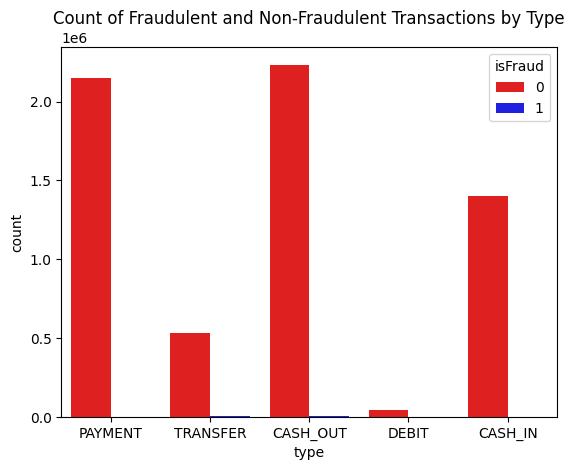

In [470]:
plot = sns.countplot(x='type', hue='isFraud', data=df, palette= ['red', 'blue'])
title = plt.title('Count of Fraudulent and Non-Fraudulent Transactions by Type')
plt.show()

### 10. Visualize Fraud Proportion by Transaction Type

*Calculate the mean of 'IsFraud' for each transaction 'Type' (which represents the proportion of fraudulent transactions). Display this proportion as a bar chart to easily compare fraud rates across types.*

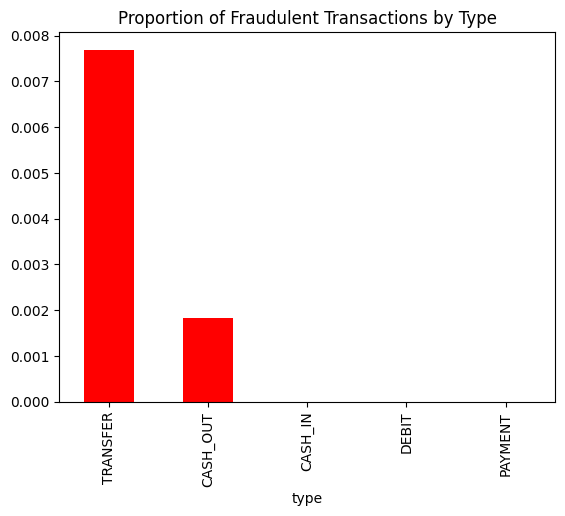

In [471]:
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', color = 'red',title = 'Proportion of Fraudulent Transactions by Type')
plt.show()

### 11. Visualize Amount Distribution by Fraud Status

*Compare the transaction amount distributions of fraudulent and non-fraudulent transactions using separate histograms. A logarithmic scale is applied to the transaction amount axis to handle its wide range and skewed distribution.*

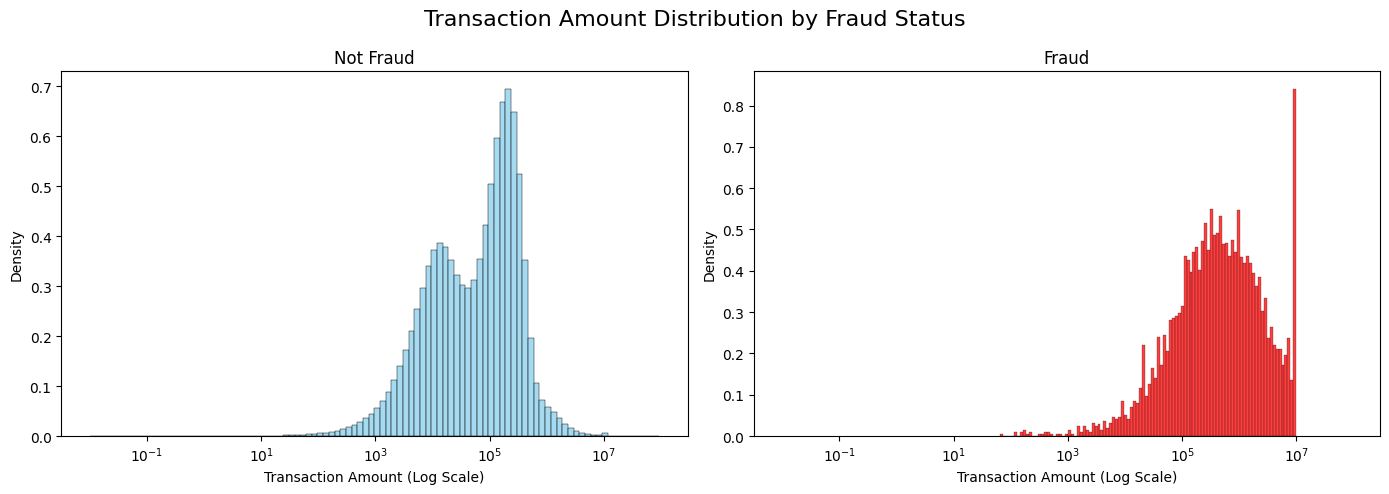

In [472]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# Not Fraud
sns.histplot(
    df[df['isFraud'] == 0]['amount'],
    bins=100,
    stat='density',
    log_scale=True,
    color='skyblue',
    ax=axes[0]
)

axes[0].set_title('Not Fraud')
axes[0].set_xlabel('Transaction Amount (Log Scale)')
axes[0].set_ylabel('Density')

# Fraud
sns.histplot(
    df[df['isFraud'] == 1]['amount'],
    bins=100,
    stat='density',
    log_scale=True,
    color='red',
    ax=axes[1]
)

axes[1].set_title('Fraud')
axes[1].set_xlabel('Transaction Amount (Log Scale)')
axes[1].set_ylabel('Density')

fig.suptitle(
    'Transaction Amount Distribution by Fraud Status',
    fontsize=16
)

plt.tight_layout()
plt.show()

### 12. Visualize Feature Correlations

*Create a heatmap using seaborn to visualize the Pearson correlation coefficient between the selected numerical features ('Step', 'Amount', 'OldbalanceOrg', 'NewbalanceOrg', 'OldbalanceDest', 'NewbalanceDest') and the target variable 'IsFraud'. Annotations show the correlation values.*

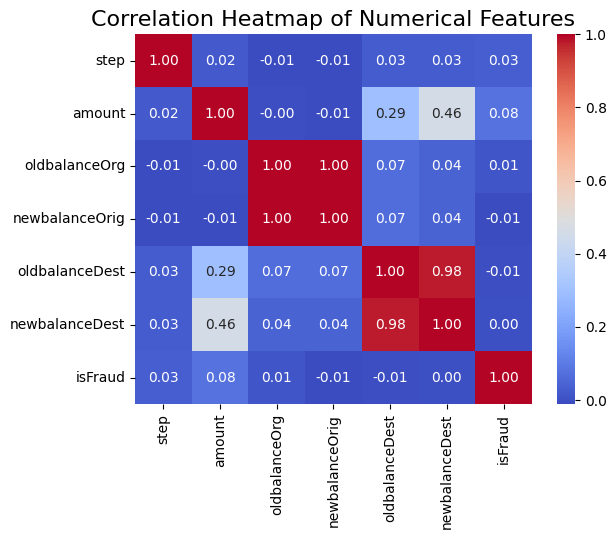

In [474]:
data = df[['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']]
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

## Data Processing and Feature Engineering ⚙️

### 13. Configure Pandas Display

*Set a global pandas display option to format floating-point numbers to two decimal places and suppress scientific notation for better readability of numerical outputs.*

In [475]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

### 14. Feature Engineering

*Create new features based on existing ones to potentially improve model performance:*
* *`ErrorBalanceOrg`: Calculates the discrepancy in the origin account balance change.*
* *`ErrorBalanceDest`: Calculates the discrepancy in the destination account balance change.*
* *`Hour_of_Day`: Extracts the hour of the day from the 'Step' feature (assuming 'Step' represents time in hours).*
* *`Day_of_Week`: Extracts the day of the week from the 'Step' feature (assuming 'Step' is hours and cycles weekly).*

In [476]:
df['ErrorBalanceOrg'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df['ErrorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df['Hour_of_Day'] = df['step'] % 24
df['Day_of_Week'] = (df['step'] // 24) % 7

### 15. Feature Selection

*Drop the 'NameOrg' and 'NameDest' columns from the DataFrame. These are likely identifier columns and may not be useful predictive features for the model. The `inplace=True` argument modifies the DataFrame directly. Display the first few rows to confirm removal.*

In [477]:
#Drop irrelevant columns
df.drop(['step','nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1, inplace=True)
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,ErrorBalanceOrg,ErrorBalanceDest,Hour_of_Day,Day_of_Week
0,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0.00,9839.64,1,0
1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,-0.00,1864.28,1,0
2,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0.00,181.00,1,0
3,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0.00,21363.00,1,0
4,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0.00,11668.14,1,0


### 16. Define Feature Sets

*Define lists containing the names of the categorical features (`categorical_features`) and numerical features (`numerical_features`) that will be used for preprocessing and model training.*

In [478]:
categorical_features = ['type']
numerical_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'ErrorBalanceOrg', 'ErrorBalanceDest', 'Hour_of_Day', 'Day_of_Week']

### 17. Create Preprocessor

*Define a `ColumnTransformer` object named `preprocessor`. This transformer will apply:*
* *`StandardScaler` to the specified `numerical_features` to standardize their scale.*
* *`OneHotEncoder` to the specified `categorical_features` to convert them into a numerical format suitable for the model.*

In [479]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_features)
])

## Model Building and Evaluation 🚀

### 18. Prepare Data for Modeling

1.  *Separate the features (independent variables) `X` by dropping the target column 'IsFraud'.*
2.  *Assign the target variable (dependent variable) 'IsFraud' to `y`.*
3.  *Split the data `X` and `y` into training and testing sets using `train_test_split`.*
    * *`test_size=0.2` reserves 20% of the data for testing.*
    * *`random_state=42` ensures reproducibility of the split.*
    * *`stratify=y` ensures that the proportion of fraudulent and non-fraudulent samples is the same in both the training and testing sets, which is important for imbalanced datasets.*

In [481]:
#Train-Test Split
X = df.drop('isFraud', axis=1)
y = df['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

### 19. Initialize Model

*Initialize a `RandomForestClassifier` model. `random_state=42` is set for reproducibility of the model's internal random processes.*

In [484]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

### 20. Create and Train Pipeline

*Create a pipeline (`ImbPipeline` from `imblearn` is used, though no specific over/under-sampling step is shown here, it allows easy integration if needed later). The pipeline first applies the `preprocessor` (scaling and encoding) and then trains the `RandomForestClassifier`. The pipeline is fitted using the training data. Then, predictions (`y_pred`) and prediction probabilities (`y_proba`) are generated for the test set.*

In [485]:
# Create the pipeline with the correct model instance
pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)])

# Train on the resampled training data
pipeline.fit(X_train, y_train)

# Test on the *original, imbalanced* test data
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

### 21. Evaluate Model Performance

*Calculate and print key performance metrics using the actual test labels (`y_test`) and the model's predictions (`y_pred`, `y_proba`):*
* **Classification Report:** *Shows precision, recall, F1-score, and support for both the fraud and non-fraud classes.*
* **AUC-ROC Score:** *Area Under the Receiver Operating Characteristic curve, measuring the model's ability to distinguish between classes across different thresholds.*
* **Precision-Recall AUC Score:** *Area Under the Precision-Recall curve, often a more informative metric for imbalanced datasets like fraud detection.*

In [486]:
 # --- Evaluation Metrics ---
print("\nClassification Report (on real-world test data):")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC Score: {roc_auc:.4f}")

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC Score: {pr_auc:.4f}")


Classification Report (on real-world test data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

AUC-ROC Score: 0.9991
Precision-Recall AUC Score: 0.9985


### 22. Feature Importance

*Feature importance was analyzed to identify the key transaction attributes contributing to the Random Forest's fraud predictions. Balance-related features and transaction amount showed the strongest predictive contribution.*

In [ ]:
# Feature Importance
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = pipeline.named_steps['classifier'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

feature_importance.head(15)

,Feature,Importance
2,num__newbalanceOrig,0.32
5,num__ErrorBalanceOrg,0.23
0,num__amount,0.10
6,num__ErrorBalanceDest,0.09
4,num__newbalanceDest,0.08
1,num__oldbalanceOrg,0.07
3,num__oldbalanceDest,0.03
13,cat__type_TRANSFER,0.03
7,num__Hour_of_Day,0.02
10,cat__type_CASH_OUT,0.02


### 23. Visualize ROC Curve

*This code plots the Receiver Operating Characteristic (ROC) curve to visualize the model's ability to distinguish between classes.*
* *It plots the* **True Positive Rate (TPR)** *against the* **False Positive Rate (FPR)**.
* *The* **Area Under the Curve (AUC)** *is shown in the legend (`roc_auc`).*
* *A dashed line represents the performance of a random classifier.*
* *Labels and a title are added for clarity*.

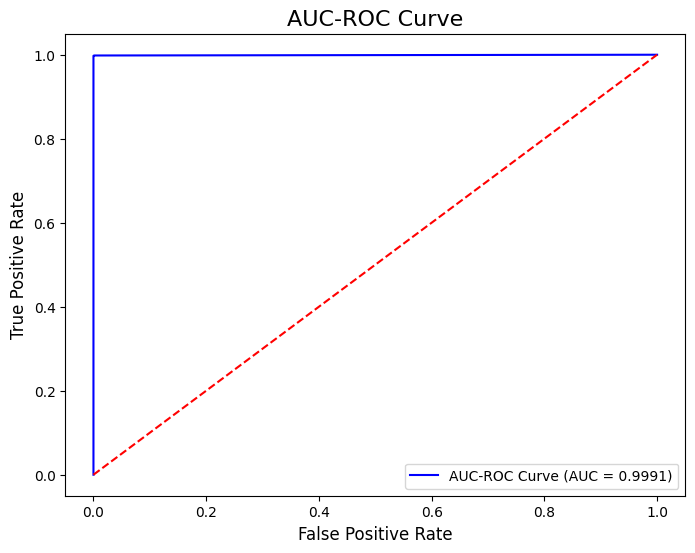

In [487]:
#AUC-ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC-ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('AUC-ROC Curve', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend()
plt.show()


### 24. Visualize Confusion Matrix

*Calculate the confusion matrix based on the test set predictions and visualize it as a heatmap. This shows the counts of true positives, true negatives, false positives, and false negatives.*


Confusion Matrix:


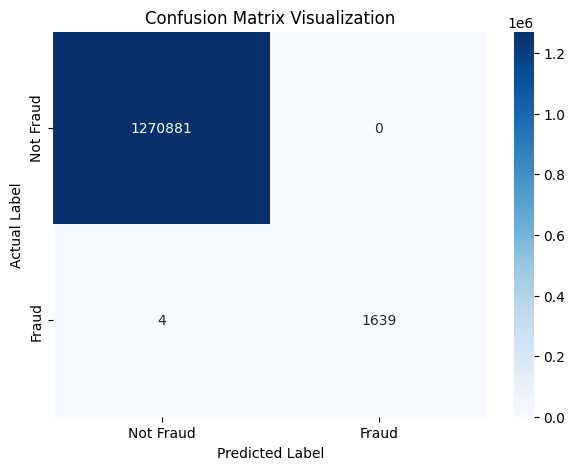

In [488]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix Visualization')
plt.show()